# Test Custom Video + Landmark Visualization

This notebook tests a custom video using the same feature logic (`EAR`, `MAR`, `pitch`, `yaw`) from `drowsy-detection.ipynb`, and draws landmarks on a black background.

In [8]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

try:
    import mediapipe as mp
except ImportError:
    raise ImportError("mediapipe is not installed. Please run: pip install mediapipe")

try:
    import joblib
except ImportError:
    joblib = None

VIDEO_PATH = r"test data/1.mp4"
SAMPLE_EVERY_N_FRAMES = 5
MAX_SAMPLED_FRAMES = 6000
WINDOW_SIZE = 15

if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(f"Video not found: {VIDEO_PATH}")

print("Video path:", VIDEO_PATH)
print("Sample stride:", SAMPLE_EVERY_N_FRAMES)

Video path: test data/1.mp4
Sample stride: 5


In [9]:
# Landmark indices from your drowsy pipeline
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]
MOUTH_TOP, MOUTH_BOTTOM, MOUTH_LEFT, MOUTH_RIGHT = 13, 14, 78, 308
NOSE, CHIN, LEFT_FACE, RIGHT_FACE = 1, 152, 234, 454

mp_face_mesh = mp.solutions.face_mesh

def compute_EAR(landmarks_xy, eye):
    p1, p2, p3, p4, p5, p6 = [np.array(landmarks_xy[i][:2]) for i in eye]
    vertical1 = np.linalg.norm(p2 - p6)
    vertical2 = np.linalg.norm(p3 - p5)
    horizontal = np.linalg.norm(p1 - p4)
    return (vertical1 + vertical2) / (2.0 * horizontal + 1e-6)

def compute_MAR(landmarks_xy):
    top = np.array(landmarks_xy[MOUTH_TOP][:2])
    bottom = np.array(landmarks_xy[MOUTH_BOTTOM][:2])
    left = np.array(landmarks_xy[MOUTH_LEFT][:2])
    right = np.array(landmarks_xy[MOUTH_RIGHT][:2])
    vertical = np.linalg.norm(top - bottom)
    horizontal = np.linalg.norm(left - right)
    return vertical / (horizontal + 1e-6)

def compute_head_pose_approx(landmarks_xy):
    nose = np.array(landmarks_xy[NOSE][:2])
    chin = np.array(landmarks_xy[CHIN][:2])
    left = np.array(landmarks_xy[LEFT_FACE][:2])
    right = np.array(landmarks_xy[RIGHT_FACE][:2])
    pitch = np.linalg.norm(nose - chin)
    yaw = np.linalg.norm(left - right)
    return pitch, yaw

def mp_landmarks_to_pixels(face_landmarks, w, h):
    out = []
    for lm in face_landmarks.landmark:
        out.append((int(lm.x * w), int(lm.y * h), lm.z))
    return out

def draw_black_landmark_face(landmarks_xy, h, w):
    black = np.zeros((h, w, 3), dtype=np.uint8)

    # Full face dots
    for (x, y, _) in landmarks_xy:
        if 0 <= x < w and 0 <= y < h:
            cv2.circle(black, (x, y), 1, (180, 180, 180), -1)

    # Highlight eyes and mouth landmarks
    for idx in LEFT_EYE + RIGHT_EYE:
        x, y = landmarks_xy[idx][:2]
        cv2.circle(black, (x, y), 3, (0, 255, 255), -1)

    for idx in [MOUTH_TOP, MOUTH_BOTTOM, MOUTH_LEFT, MOUTH_RIGHT]:
        x, y = landmarks_xy[idx][:2]
        cv2.circle(black, (x, y), 4, (0, 0, 255), -1)

    # Draw mouth measurement lines
    p13 = tuple(landmarks_xy[MOUTH_TOP][:2])
    p14 = tuple(landmarks_xy[MOUTH_BOTTOM][:2])
    p78 = tuple(landmarks_xy[MOUTH_LEFT][:2])
    p308 = tuple(landmarks_xy[MOUTH_RIGHT][:2])
    cv2.line(black, p13, p14, (0, 0, 255), 2)
    cv2.line(black, p78, p308, (0, 0, 255), 2)

    return black

In [10]:
# Extract features and capture one visualization frame
rows = []
frame_vis_bgr = None
black_vis_bgr = None
sampled_count = 0
face_ok_count = 0

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

with mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as face_mesh:
    frame_id = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_id += 1
        if frame_id % SAMPLE_EVERY_N_FRAMES != 0:
            continue

        sampled_count += 1
        if sampled_count > MAX_SAMPLED_FRAMES:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = face_mesh.process(rgb)
        if not result.multi_face_landmarks:
            continue

        h, w, _ = frame.shape
        face_landmarks = result.multi_face_landmarks[0]
        landmarks_xy = mp_landmarks_to_pixels(face_landmarks, w, h)

        try:
            left_ear = compute_EAR(landmarks_xy, LEFT_EYE)
            right_ear = compute_EAR(landmarks_xy, RIGHT_EYE)
            ear = (left_ear + right_ear) / 2.0
            mar = compute_MAR(landmarks_xy)
            pitch, yaw = compute_head_pose_approx(landmarks_xy)
        except Exception:
            continue

        face_ok_count += 1
        rows.append({
            "frame": frame_id,
            "EAR": ear,
            "MAR": mar,
            "pitch": pitch,
            "yaw": yaw,
            "video_path": VIDEO_PATH
        })

        # Save one representative frame and black landmark render
        if frame_vis_bgr is None:
            draw = frame.copy()
            for (x, y, _) in landmarks_xy:
                cv2.circle(draw, (x, y), 1, (0, 255, 0), -1)
            frame_vis_bgr = draw
            black_vis_bgr = draw_black_landmark_face(landmarks_xy, h, w)

cap.release()

features_df = pd.DataFrame(rows)
print(f"Sampled frames: {sampled_count}")
print(f"Detected-face frames: {face_ok_count}")
print(f"Extracted rows: {len(features_df)}")

if len(features_df) == 0:
    raise RuntimeError("No features extracted. Try reducing SAMPLE_EVERY_N_FRAMES or using another video.")

features_df.to_csv("test_video_features.csv", index=False)
print("Saved: test_video_features.csv")
display(features_df.head())

e:\miniconda3\envs\whisper\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Sampled frames: 127
Detected-face frames: 127
Extracted rows: 127
Saved: test_video_features.csv


,frame,EAR,MAR,pitch,yaw,video_path
0,5,0.108303,0.000000,41.303753,85.052925,test data/1.mp4
1,10,0.097542,0.038462,41.303753,84.005952,test data/1.mp4
2,15,0.085880,0.038462,41.109610,83.006024,test data/1.mp4
3,20,0.062892,0.120000,42.296572,84.000000,test data/1.mp4
4,25,0.080679,0.307692,44.407207,83.006024,test data/1.mp4


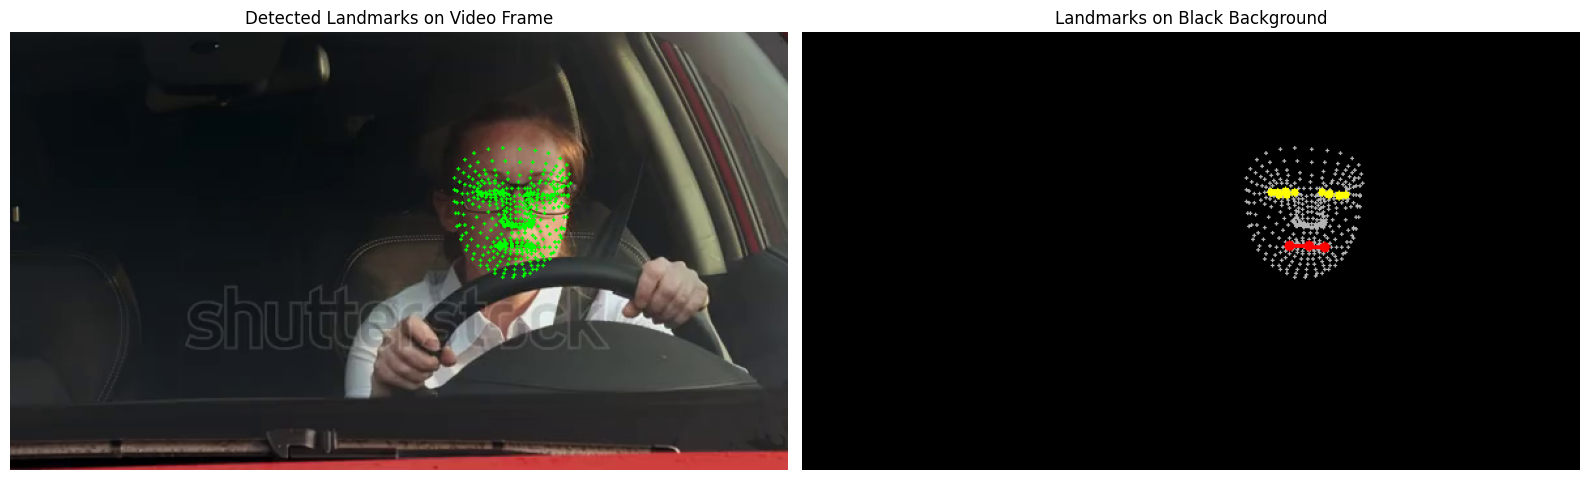

Feature summary:


,count,mean,std,min,25%,50%,75%,max
EAR,127.0,0.134138,0.043016,0.027400,0.10250,0.131605,0.160069,0.249777
MAR,127.0,0.154095,0.266171,0.000000,0.00000,0.000000,0.233345,1.000000
pitch,127.0,41.375267,5.357890,24.596748,39.00000,41.012193,45.945588,50.487622
yaw,127.0,83.544313,3.196191,73.824115,82.02743,83.216585,86.023253,89.202018


In [11]:
# Show landmark visualization
if frame_vis_bgr is None or black_vis_bgr is None:
    raise RuntimeError("No visualization frame available.")

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].imshow(cv2.cvtColor(frame_vis_bgr, cv2.COLOR_BGR2RGB))
ax[0].set_title("Detected Landmarks on Video Frame")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(black_vis_bgr, cv2.COLOR_BGR2RGB))
ax[1].set_title("Landmarks on Black Background")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print("Feature summary:")
display(features_df[["EAR", "MAR", "pitch", "yaw"]].describe().T)

In [12]:
# Optional model prediction using saved files from drowsy-detection.ipynb
model_files = ["random_forest_model.pkl", "label_encoder.pkl", "feature_columns.pkl"]
have_model = all(os.path.exists(p) for p in model_files) and (joblib is not None)

if not have_model:
    print("Model files not found (or joblib missing). Skipping prediction.")
    print("Expected files:", model_files)
else:
    model = joblib.load("random_forest_model.pkl")
    le = joblib.load("label_encoder.pkl")
    feature_columns = joblib.load("feature_columns.pkl")

    # Build normalized dev features (fallback: raw if no baseline)
    data = features_df.copy()
    data["EAR_dev"] = data["EAR"]
    data["MAR_dev"] = data["MAR"]

    windows = []
    if len(data) >= WINDOW_SIZE:
        for i in range(len(data) - WINDOW_SIZE + 1):
            chunk = data.iloc[i:i + WINDOW_SIZE]
            windows.append({
                "EAR_mean": chunk["EAR"].mean(),
                "EAR_std": chunk["EAR"].std(),
                "EAR_min": chunk["EAR"].min(),
                "MAR_mean": chunk["MAR"].mean(),
                "MAR_max": chunk["MAR"].max(),
                "pitch_mean": chunk["pitch"].mean(),
                "yaw_mean": chunk["yaw"].mean(),
                "EAR_dev_mean": chunk["EAR_dev"].mean(),
                "MAR_dev_mean": chunk["MAR_dev"].mean()
            })

    window_df = pd.DataFrame(windows)
    if len(window_df) == 0:
        print(f"Not enough rows for window prediction. Need at least {WINDOW_SIZE} rows.")
    else:
        X_new = window_df[feature_columns]
        pred_encoded = model.predict(X_new)
        pred_labels = le.inverse_transform(pred_encoded)
        counts = Counter(pred_labels)
        final_prediction = counts.most_common(1)[0][0]

        print("Window prediction counts:")
        for cls, cnt in counts.items():
            print(f"- {cls}: {cnt}")

        print("Final video prediction:", final_prediction)

        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_new).mean(axis=0)
            prob_df = pd.DataFrame({
                "class": le.classes_,
                "avg_probability": probs
            }).sort_values("avg_probability", ascending=False)
            display(prob_df)

e:\miniconda3\envs\whisper\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Window prediction counts:
- Drowsy: 113
Final video prediction: Drowsy


e:\miniconda3\envs\whisper\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
e:\miniconda3\envs\whisper\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,class,avg_probability
1,Drowsy,0.836195
0,Alert,0.106991
2,Low Vigilance,0.056814
